# Analysis of Low Birth Rates Across Italian Regions Using Socio-Economic and Demographic Indicators

## 1. Introduction
Italy has experienced a persistent decline in fertility over recent decades, with substantial differences across regions. [MENTION PAPERS] This analysis examines regional fertility patterns using socio-economic and demographic indicators to identify factors associated with low birth rates.

Using two panel datasets covering Italian regions over time, the study first explores descriptive trends and correlations between fertility and key variables. It then applies Random Forest models to capture non-linear relationships and assess the relative importance of demographic structure, labor market conditions, housing costs, family formation, welfare usage, and childcare availability in predicting regional fertility rates.

The objective is not causal inference, but to provide an empirical and data-driven assessment of which factors are most strongly associated with fertility differences across Italian regions.

## 2. Data
The analysis is based exclusively on data from the Italian National Institute of Statistics (ISTAT), ensuring full consistency and comparability across indicators. All variables are collected at the regional level and organized in a panel structure covering multiple years.

In order to align with academic practices and solve missing years of data two different datasets were constructed:
- A long-run dataset covering the period 2011–2024, only including variables with consistent availability over time.
- A short-term dataset covering 2018–2024, which incorporates additional socio-economic indicators with more limited historical coverage.

This dual-dataset strategy allows the analysis to exploit long-term regional trends while also examining the role of more recent labor market and policy-related factors. Descriptive analysis, correlation analysis, and machine-learning models are applied to these datasets to assess associations between fertility and its potential determinants.

In [44]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR = Path('data/dataset')
lr_path = DATA_DIR / 'dataset_lr.csv'
st_path = DATA_DIR / 'dataset_st.csv'

In [42]:
lr = pd.read_csv(lr_path)
st = pd.read_csv(st_path)

print('LR shape:', lr.shape, '| years:', lr.year.min(), '-', lr.year.max())
print('ST shape:', st.shape, '| years:', st.year.min(), '-', st.year.max())


LR shape: (280, 17) | years: 2011 - 2024
ST shape: (140, 17) | years: 2018 - 2024



### 2.1 Dependent Variable

The dependent variable is the Total Fertility Rate (TFR), defined as the average number of children a woman would have over her lifetime if current age-specific fertility rates remained constant. Regional TFR data are obtained from ISTAT’s demographic database on natality and fertility indicators. (TFR source: ISTAT – Natality and fertility statistics)

### 2.2 Independent Variables

To capture the main demographic, socio-economic, and institutional determinants of fertility, the following regional indicators are included:
- Female employment rate (15–64), measuring labor market participation among women of working age, sourced from ISTAT labor force statistics.
- Average regional disposable income, used as a proxy for household economic resources and income security.
- Education level of women, measured as the share of women aged 25–34 holding a tertiary degree, capturing human capital and fertility  - postponement effects.
- Housing cost index, reflecting regional differences in housing affordability and living costs.
- Share of women aged 25–39, calculated from regional population data, representing the core reproductive-age population.
- Share of foreign residents, capturing demographic composition and the contribution of migration to regional fertility patterns.
- Marriage indicators, including marriage rates and average age at first marriage, used to account for family formation timing.
- Availability of childcare services for children aged 0–3, measured through indicators on authorized nursery places and early childhood services.
- Public spending on families and social policies, reflecting the regional level of institutional support for households with children.
- Employment stability, proxied by indicators on permanent employment contracts, capturing job security and economic uncertainty.

All variables are harmonized to ensure temporal and spatial comparability across regions.


### 3 Exploratory Data Analysis

In this section we are going to get a first introduction of our dataset


In [30]:
print('Missing values (LR):', lr.isna().sum())
print('Missing values (ST):', st.isna().sum())

Missing values (LR): region                                   0
year                                     0
tfr                                      0
share_pop_25_39                          0
median_age                               0
population_total                         0
welfare_users                            0
female_employment_rate                   0
salary_avg_hourly                        0
weddings_total                           0
marriage_age_mean                        0
housing_cost_ratio                       0
employment_stability_ratio               0
childcare_places_per_100_children_0_2    0
youth_unemployment_rate_15_34            0
foreign_population                       0
foreign_population_share                 0
dtype: int64
Missing values (ST): region                                   0
year                                     0
tfr                                      0
share_pop_25_39                          0
median_age                               0


## Peek at data
Quick look at the first few rows of the long-range dataset.


In [31]:
lr.head()


,region,year,tfr,share_pop_25_39,median_age,population_total,welfare_users,female_employment_rate,salary_avg_hourly,weddings_total,marriage_age_mean,housing_cost_ratio,employment_stability_ratio,childcare_places_per_100_children_0_2,youth_unemployment_rate_15_34,foreign_population,foreign_population_share
0,Abruzzo,2011,1.32,0.20,44.0,1329220.0,19.0,28.06,11.92,415.5,31.65,13.6,0.81,15.14,26.91,82589.00,0.06
1,Abruzzo,2012,1.33,0.20,44.0,1331624.0,18.4,28.78,12.02,431.3,31.91,12.2,0.81,16.11,25.97,82666.29,0.06
2,Abruzzo,2013,1.30,0.19,44.0,1332583.0,18.7,29.49,12.13,441.2,31.92,12.0,0.81,17.80,25.04,82743.57,0.06
3,Abruzzo,2014,1.30,0.19,45.0,1329918.0,18.1,30.21,12.29,408.0,32.24,10.9,0.81,18.60,24.11,82820.86,0.06
4,Abruzzo,2015,1.29,0.19,45.0,1325836.0,19.2,30.93,12.38,415.2,32.58,10.2,0.81,18.40,23.18,82898.14,0.06



## Summary statistics
Descriptive stats for numeric columns (mean, std, min, max) for both datasets.


In [33]:
stats_lr = lr.describe().T[['mean','std','min','max']]
stats_lr


,mean,std,min,max
year,2.017500e+03,4.038347e+00,2011.00,2024.00
tfr,1.284429e+00,1.342857e-01,0.91,1.65
share_pop_25_39,1.738214e-01,1.689214e-02,0.14,0.21
median_age,4.614536e+01,2.415967e+00,39.00,52.00
population_total,2.988700e+06,2.443237e+06,122877.00,10027602.00
welfare_users,1.708871e+01,6.022842e+00,4.89,30.50
female_employment_rate,3.489746e+01,7.891440e+00,17.67,47.09
salary_avg_hourly,1.333279e+01,1.282947e+00,10.88,16.92
weddings_total,4.266734e+02,9.940509e+01,139.60,656.50
marriage_age_mean,3.411018e+01,2.120596e+00,29.53,39.29


In [35]:
stats_st = st.describe().T[['mean','std','min','max']]
stats_st

,mean,std,min,max
year,2.021000e+03,2.007181e+00,2018.00,2024.00
tfr,1.217000e+00,1.144628e-01,0.91,1.59
share_pop_25_39,1.634286e-01,1.179998e-02,0.14,0.19
median_age,4.757929e+01,1.893096e+00,42.00,52.00
population_total,2.968785e+06,2.450286e+06,122877.00,10027602.00
welfare_users,1.667729e+01,6.397215e+00,4.89,30.50
female_employment_rate,3.634579e+01,7.667416e+00,21.93,47.09
salary_avg_hourly,1.366786e+01,1.242960e+00,11.31,16.92
weddings_total,3.978877e+02,1.115897e+02,139.60,656.50
marriage_age_mean,3.529179e+01,1.958013e+00,31.29,39.29



## Correlations with TFR
Correlation of each numeric feature with the dependent variable `tfr`.


In [39]:
corr_lr = lr.drop(columns=['region']).corr(numeric_only=True)['tfr'].sort_values(ascending=False)
corr_lr


tfr                                      1.000000
housing_cost_ratio                       0.473450
share_pop_25_39                          0.354669
foreign_population                       0.326979
foreign_population_share                 0.269582
population_total                         0.231924
weddings_total                           0.186799
salary_avg_hourly                        0.099459
youth_unemployment_rate_15_34            0.070486
female_employment_rate                   0.053923
employment_stability_ratio               0.029255
welfare_users                           -0.050226
childcare_places_per_100_children_0_2   -0.225726
marriage_age_mean                       -0.320515
year                                    -0.552745
median_age                              -0.575117
Name: tfr, dtype: float64

In [40]:
corr_st = st.drop(columns=['region']).corr(numeric_only=True)['tfr'].sort_values(ascending=False)
corr_st

tfr                                      1.000000
housing_cost_ratio                       0.350011
share_pop_25_39                          0.274526
foreign_population                       0.268914
population_total                         0.233148
weddings_total                           0.225931
foreign_population_share                 0.187251
youth_unemployment_rate_15_34            0.117760
salary_avg_hourly                        0.043300
employment_stability_ratio              -0.046302
female_employment_rate                  -0.065524
welfare_users                           -0.280511
marriage_age_mean                       -0.302512
childcare_places_per_100_children_0_2   -0.304714
year                                    -0.310319
median_age                              -0.577484
Name: tfr, dtype: float64


## 3.1 TFR Over Time by Region
Now that we have checked for the shape and NAs in our datasets (lr and sr) let's look at how our dependent variable evolved over time for each region.

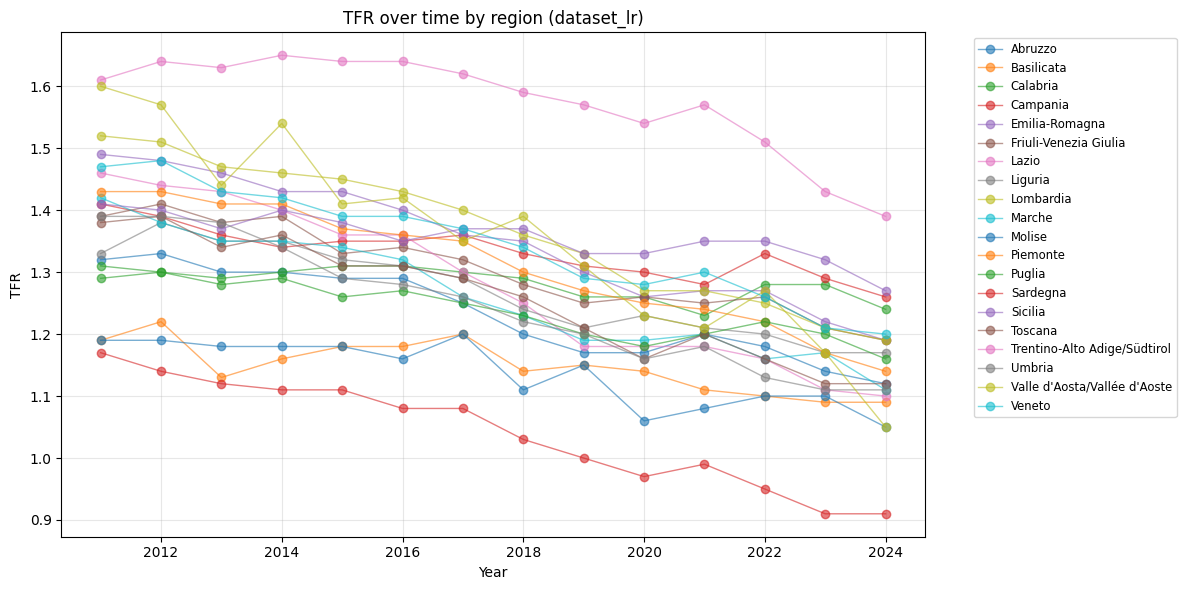

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))
for region, grp in lr.sort_values(['region','year']).groupby('region'):
    ax.plot(grp['year'], grp['tfr'], marker='o', linewidth=1, alpha=0.6, label=region)
ax.set_title('TFR over time by region (dataset_lr)')
ax.set_xlabel('Year')
ax.set_ylabel('TFR')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()


As you can see:
- TFR declines over time in almost all regions, indicating a strong common downward trend.
- Regions start from different fertility levels and largely retain their relative ranking, pointing to persistent regional heterogeneity.
- Despite this, there is substantial within-region variation over time, suggesting fertility responds to changing local conditions.
- The broadly synchronized movements across regions motivate the inclusion of year fixed effects, while stable level differences motivate region fixed effects.
- Together, these patterns support a two-way fixed-effects panel approach focused on within-region fertility dynamics.


## 3.2 Pairwise Correlations Among Predictors
Compute the correlation matrix across predictors (excluding `region` and `tfr`).


In [49]:
predictors = [c for c in st.columns if c not in ['region', 'tfr']]
corr_matrix = st[predictors].corr(numeric_only=True)
corr_matrix

,year,share_pop_25_39,median_age,population_total,welfare_users,female_employment_rate,salary_avg_hourly,weddings_total,marriage_age_mean,housing_cost_ratio,employment_stability_ratio,childcare_places_per_100_children_0_2,youth_unemployment_rate_15_34,foreign_population,foreign_population_share
year,1.000000,-0.321976,0.435466,-0.007530,0.034962,0.108302,0.208977,-0.002939,0.322562,-0.305790,0.099862,0.225687,-0.320445,0.015036,0.047593
share_pop_25_39,-0.321976,1.000000,-0.849924,0.253773,-0.324406,-0.664339,-0.488925,0.370149,-0.735774,0.079511,-0.508027,-0.688791,0.694984,-0.018313,-0.502155
median_age,0.435466,-0.849924,1.000000,-0.368336,0.394338,0.548696,0.367272,-0.356950,0.706926,-0.245334,0.435198,0.639380,-0.629370,-0.151567,0.320533
population_total,-0.007530,0.253773,-0.368336,1.000000,-0.101752,0.144834,0.549387,-0.058723,0.147225,0.237056,0.329056,0.025831,-0.079026,0.847814,0.305721
welfare_users,0.034962,-0.324406,0.394338,-0.101752,1.000000,0.553034,0.259625,-0.201622,0.310137,-0.130839,0.382024,0.464598,-0.597927,0.169805,0.308187
female_employment_rate,0.108302,-0.664339,0.548696,0.144834,0.553034,1.000000,0.771436,-0.549466,0.830369,-0.184021,0.816481,0.901756,-0.918622,0.499716,0.888146
salary_avg_hourly,0.208977,-0.488925,0.367272,0.549387,0.259625,0.771436,1.000000,-0.448944,0.763466,0.112095,0.824184,0.687030,-0.723377,0.789768,0.808915
weddings_total,-0.002939,0.370149,-0.356950,-0.058723,-0.201622,-0.549466,-0.448944,1.000000,-0.674325,0.215717,-0.614065,-0.559893,0.493793,-0.257130,-0.451875
marriage_age_mean,0.322562,-0.735774,0.706926,0.147225,0.310137,0.830369,0.763466,-0.674325,1.000000,-0.174001,0.758858,0.872357,-0.801316,0.356640,0.708034
housing_cost_ratio,-0.305790,0.079511,-0.245334,0.237056,-0.130839,-0.184021,0.112095,0.215717,-0.174001,1.000000,-0.003730,-0.294998,0.278578,0.176822,-0.062796


In [ ]:
predictors = [c for c in lr.columns if c not in ['region', 'tfr']]
corr_matrix = lr[predictors].corr(numeric_only=True)
corr_matrix


,year,share_pop_25_39,median_age,population_total,welfare_users,female_employment_rate,salary_avg_hourly,weddings_total,marriage_age_mean,housing_cost_ratio,employment_stability_ratio,childcare_places_per_100_children_0_2,youth_unemployment_rate_15_34,foreign_population,foreign_population_share
year,1.000000,-0.706429,0.684866,-0.008786,-0.055202,0.211731,0.315401,-0.272074,0.627180,-0.502845,0.203407,0.393601,-0.477661,0.031272,0.107683
share_pop_25_39,-0.706429,1.000000,-0.874437,0.198062,-0.180141,-0.562731,-0.558841,0.469305,-0.823489,0.287793,-0.481415,-0.671839,0.721648,-0.042066,-0.403937
median_age,0.684866,-0.874437,1.000000,-0.272674,0.279970,0.556769,0.490591,-0.508943,0.812818,-0.341295,0.442004,0.703139,-0.696154,-0.072248,0.338916
population_total,-0.008786,0.198062,-0.272674,1.000000,-0.054104,0.147076,0.473617,-0.032961,0.049043,0.321052,0.260531,-0.024450,-0.022094,0.838005,0.302260
welfare_users,-0.055202,-0.180141,0.279970,-0.054104,1.000000,0.605464,0.303915,-0.331982,0.270970,-0.082273,0.351301,0.457881,-0.569465,0.240093,0.412537
female_employment_rate,0.211731,-0.562731,0.556769,0.147076,0.605464,1.000000,0.810123,-0.681484,0.787041,-0.078279,0.715243,0.889205,-0.883291,0.525631,0.880804
salary_avg_hourly,0.315401,-0.558841,0.490591,0.473617,0.303915,0.810123,1.000000,-0.570374,0.766861,0.121776,0.751967,0.708655,-0.747325,0.744931,0.799606
weddings_total,-0.272074,0.469305,-0.508943,-0.032961,-0.331982,-0.681484,-0.570374,1.000000,-0.725052,0.226097,-0.600673,-0.693375,0.659088,-0.303051,-0.529791
marriage_age_mean,0.627180,-0.823489,0.812818,0.049043,0.270970,0.787041,0.766861,-0.725052,1.000000,-0.280179,0.636037,0.873216,-0.829425,0.303626,0.631892
housing_cost_ratio,-0.502845,0.287793,-0.341295,0.321052,-0.082273,-0.078279,0.121776,0.226097,-0.280179,1.000000,0.081907,-0.255132,0.253979,0.232385,0.045696



## 3.3 Multicollinearity Check (VIF)
Variance Inflation Factors (VIF) for predictors to assess multicollinearity.


In [50]:
X = st[predictors].copy()
X = X.assign(constant=1.0)
vif_data = []
for i, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, i)
    vif_data.append((col, vif))

vif_df = pd.DataFrame(vif_data, columns=['variable', 'vif'])
print(vif_df.sort_values('vif', ascending=False))

                                 variable           vif
15                               constant  2.341819e+06
5                  female_employment_rate  3.322171e+01
8                       marriage_age_mean  1.993650e+01
13                     foreign_population  1.903400e+01
6                       salary_avg_hourly  1.696099e+01
12          youth_unemployment_rate_15_34  1.259080e+01
11  childcare_places_per_100_children_0_2  1.012054e+01
3                        population_total  1.009851e+01
14               foreign_population_share  9.646532e+00
2                              median_age  8.715460e+00
1                         share_pop_25_39  6.394001e+00
10             employment_stability_ratio  5.815096e+00
7                          weddings_total  3.472134e+00
4                           welfare_users  3.282574e+00
0                                    year  2.324517e+00
9                      housing_cost_ratio  2.262029e+00


In [48]:
X = lr[predictors].copy()
X = X.assign(constant=1.0)
vif_data = []
for i, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, i)
    vif_data.append((col, vif))

vif_df = pd.DataFrame(vif_data, columns=['variable', 'vif'])
print(vif_df.sort_values('vif', ascending=False))


                                 variable           vif
15                               constant  1.496463e+06
5                  female_employment_rate  2.732188e+01
8                       marriage_age_mean  2.004978e+01
13                     foreign_population  1.681416e+01
6                       salary_avg_hourly  1.641742e+01
12          youth_unemployment_rate_15_34  1.105820e+01
11  childcare_places_per_100_children_0_2  1.038054e+01
2                              median_age  9.126093e+00
3                        population_total  7.891232e+00
14               foreign_population_share  7.640827e+00
1                         share_pop_25_39  7.416142e+00
0                                    year  6.041508e+00
4                           welfare_users  3.098538e+00
7                          weddings_total  3.091754e+00
10             employment_stability_ratio  2.837747e+00
9                      housing_cost_ratio  2.207960e+00


## 3.4 Stationarity Tests (ADF)
Augmented Dickey-Fuller tests for `tfr` and main predictors.


In [51]:

from statsmodels.tsa.stattools import adfuller

series_to_test = ['tfr', 'welfare_users', 'female_employment_rate', 'salary_avg_hourly', 'weddings_total',
                  'marriage_age_mean', 'housing_cost_ratio', 'employment_stability_ratio',
                  'childcare_places_per_100_children_0_2', 'youth_unemployment_rate_15_34',
                  'foreign_population_share']

for col in series_to_test:
    if col not in lr.columns:
        continue
    s = lr.sort_values(['region','year'])[col].dropna()
    stat, pvalue, _, _, crit, _ = adfuller(s)
    print(f"ADF for {col}: stat={stat:.3f}, p-value={pvalue:.4f}, critical={crit}")


ADF for tfr: stat=-4.004, p-value=0.0014, critical={'1%': np.float64(-3.4552699038400827), '5%': np.float64(-2.8725092359464526), '10%': np.float64(-2.5726152830188678)}
ADF for welfare_users: stat=-4.081, p-value=0.0010, critical={'1%': np.float64(-3.4544435065994437), '5%': np.float64(-2.8721468827772774), '10%': np.float64(-2.572422013959188)}
ADF for female_employment_rate: stat=-3.406, p-value=0.0108, critical={'1%': np.float64(-3.4540076534999957), '5%': np.float64(-2.8719557347997178), '10%': np.float64(-2.5723200648758366)}
ADF for salary_avg_hourly: stat=-2.893, p-value=0.0462, critical={'1%': np.float64(-3.4552699038400827), '5%': np.float64(-2.8725092359464526), '10%': np.float64(-2.5726152830188678)}
ADF for weddings_total: stat=-3.256, p-value=0.0170, critical={'1%': np.float64(-3.455365238788105), '5%': np.float64(-2.8725510317187024), '10%': np.float64(-2.5726375763314966)}
ADF for marriage_age_mean: stat=-3.564, p-value=0.0065, critical={'1%': np.float64(-3.455269903840